In [19]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import colors

In [5]:
data_LR = np.loadtxt('C:\\Users\\kl89\\MS Window Project\\Comsol Exports\\FOM_forwards_sweep_A_gamma_lam.txt', skiprows=5)
print(data_LR.shape)
data_RL = np.loadtxt('C:\\Users\\kl89\\MS Window Project\\Comsol Exports\\FOM_backwards_sweep_A_gamma_lam.txt', skiprows=5)
print(data_RL.shape)
cols = {
    "gamma": 0,
    "A": 1,
    "lam": 2,
    "trans": 3,
    "emiss": 4,
    "FOM_bulk": 5
}
int_cols = {
    "gamma": 0,
    "A": 1,
    "FOM_KK": 2,
    "FOM_bulk": 3
}
num_rows = len(data_LR)

(130000, 6)
(130000, 6)


In [7]:
lams_unique = np.unique(data_LR[:, cols["lam"]])
delta_lamb = lams_unique[-1] - lams_unique[0]
num_lams = len(lams_unique)
trans = np.zeros_like(lams_unique)
emiss = np.zeros_like(lams_unique)
FOM_bulk = np.zeros_like(lams_unique)
data_LR_integrated = np.empty([int(num_rows/(num_lams)), 4])
print(delta_lamb)

2.5


In [9]:
for i in range(len(data_LR_integrated)):
    data_LR_integrated[i, int_cols["gamma"]] = data_LR[i*num_lams, cols["gamma"]]
    data_LR_integrated[i, int_cols["A"]] = data_LR[i*num_lams, cols["A"]]
    for j in range(num_lams):
        trans[j] = data_LR[i*num_lams + j, cols["trans"]]
        emiss[j] = data_LR[i*num_lams + j, cols["emiss"]]
        FOM_bulk[j] = data_LR[i*num_lams + j, cols["FOM_bulk"]]
    data_LR_integrated[i, int_cols["FOM_KK"]] = (np.trapz(trans, x=lams_unique))**2 / np.trapz(emiss, x=lams_unique) / delta_lamb
    data_LR_integrated[i, int_cols["FOM_bulk"]] = np.trapz(FOM_bulk, x=lams_unique) / delta_lamb 

np.savetxt('C:\\Users\\kl89\\MS Window Project\\Comsol Exports\\FOM_integrated_forwards_sweep_A_gamma_final.txt', data_LR_integrated, fmt='%f')    

<function matplotlib.pyplot.show(close=None, block=None)>

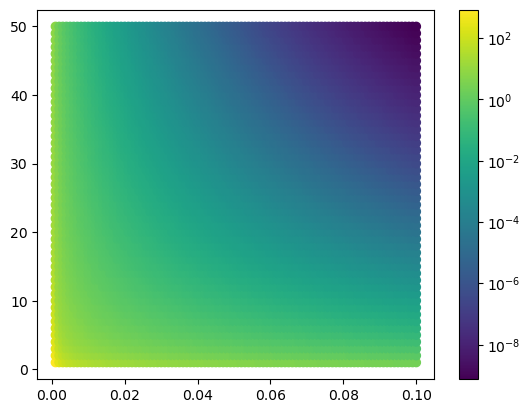

In [39]:
gammas_unique = data_LR_integrated[:, int_cols["gamma"]]
As_unique = data_LR_integrated[:, int_cols["A"]]
FOM_KK = data_LR_integrated[:, int_cols["FOM_KK"]]
FOM_bulk = data_LR_integrated[:, int_cols["FOM_bulk"]]
plt.scatter(gammas_unique,As_unique,c=FOM_bulk, norm=colors.LogNorm()) 
plt.colorbar()
plt.show

In [25]:
print(data_LR[11934])

[ 0.01       10.          2.5         0.625606    0.37436085  1.06539647]


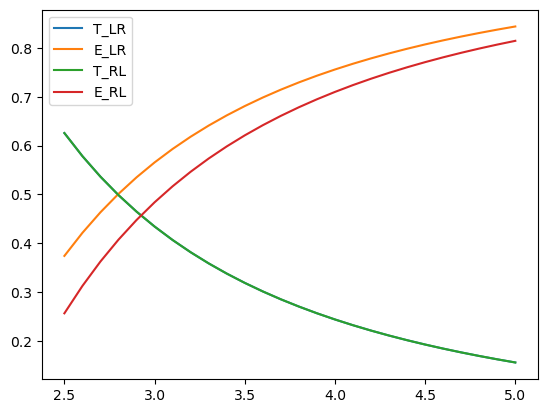

In [37]:
trans_LR_ex1 = np.zeros_like(lams_unique)
emiss_LR_ex1 = np.zeros_like(lams_unique)
FOM_bulk_LR_ex1 = np.zeros_like(lams_unique)
trans_RL_ex1 = np.zeros_like(lams_unique)
emiss_RL_ex1 = np.zeros_like(lams_unique)
FOM_bulk_RL_ex1 = np.zeros_like(lams_unique)
for i in range(num_lams):
    trans_LR_ex1[i] = data_LR[11934+i, cols['trans']]
    emiss_LR_ex1[i] = data_LR[11934+i, cols['emiss']]
    FOM_bulk_LR_ex1[i] = data_LR[11934+i, cols['FOM_bulk']]
    trans_RL_ex1[i] = data_RL[11934+i, cols['trans']]
    emiss_RL_ex1[i] = data_RL[11934+i, cols['emiss']]
    FOM_bulk_RL_ex1[i] = data_RL[11934+i, cols['FOM_bulk']]

plt.figure()
plt.plot(lams_unique, trans_LR_ex1, label='T_LR')
plt.plot(lams_unique, emiss_LR_ex1, label='E_LR')
#plt.plot(lams_unique, FOM_bulk_LR_ex1, label='FOM_LR')
plt.plot(lams_unique, trans_RL_ex1, label='T_RL')
plt.plot(lams_unique, emiss_RL_ex1, label='E_RL')
#plt.plot(lams_unique, FOM_bulk_RL_ex1, label='FOM_RL')
plt.legend(loc='upper left')
    